
# 3D-CNN Señas — Integración (preentrenado / (2+1)D + atención)

Este notebook integra tu **pipeline original (LMDB + entrenamiento/validación/test)** con:
- Arquitectura **(2+1)D** con *stem* profundo y **CBAM/SE** + **Atención temporal**.
- **Backbones preentrenados** (`r2plus1d_18` o `r3d_18` en Kinetics-400) + atención temporal.
- `CosineAnnealingWarmRestarts`, optimizadores (AdamW / SGD / Ranger*), **Focal Loss** opcional, métricas ampliadas.
- Guardado del **mejor modelo por F1 macro** y reportes (clasificación y matriz de confusión).

> **Cómo usar**: Ajusta las rutas (`LMDB_DIR`, `OUTDIR`) y elige la variante en la celda de **Configuración** (`VARIANT` y `BACKBONE`). Luego ejecuta todo.


In [2]:
# Configuración y librerías

import os, time, random, pickle, math, json
import numpy as np
import cv2
import lmdb
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score, average_precision_score

# Rutas (ajusta según tu entorno)
LMDB_DIR = r"D:\NUEVO\Dataset_Preprocesado"
OUTDIR   = r"."

# Hiperparámetros base
NUM_FRAMES   = 24
FRAME_SIZE   = (128, 128)
BATCH_SIZE   = 32
EPOCHS       = 60
INIT_LR      = 2e-4
WEIGHT_DECAY = 7e-4
LABEL_SMOOTH = 0.08
DROPOUT      = 0.5
PATIENCE     = 5

# Variante de modelo
#   VARIANT = "pretrained" | "2p1d"
#   BACKBONE = "r2plus1d_18" | "r3d_18"  (si VARIANT = "pretrained")
VARIANT   = "pretrained"
BACKBONE  = "r2plus1d_18"

# Optimizador: "adamw" | "sgd" | "ranger"
OPTIMIZER = "adamw"

# Pérdida: "focal" | "ce"
LOSS_NAME = "focal"
FOCAL_GAMMA = 2.0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Reproducibilidad
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


c:\Users\Cesar\anaconda3\envs\Sign_Language\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [3]:
# Dataset LMDB

class LMDBVideoDataset(Dataset):
    def __init__(self, lmdb_path, num_frames=24, frame_size=(128,128), mode='train'):
        self.lmdb_path = lmdb_path
        self.num_frames = num_frames
        self.frame_size = frame_size
        self.mode = mode

        self.env = lmdb.open(lmdb_path, readonly=True, lock=False, readahead=False, meminit=False)
        with self.env.begin() as txn:
            self.length = txn.stat()["entries"]

        # Obtener clases únicas
        self.class_names = self._extract_class_names()
        self.class_to_idx = {c: i for i, c in enumerate(sorted(self.class_names))}
        self.idx_to_class = {i: c for c, i in self.class_to_idx.items()}

    def _extract_class_names(self):
        class_names = set()
        with self.env.begin() as txn:
            for _, value in txn.cursor():
                item = pickle.loads(value)
                class_names.add(item['class'])
        return list(class_names)

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        key = f"{idx}".encode()
        with self.env.begin() as txn:
            data = txn.get(key)
        if data is None:
            raise IndexError(f"Índice {idx} no encontrado en {self.lmdb_path}")

        sample = pickle.loads(data)
        frames = sample['frames']
        label = self.class_to_idx[sample['class']]

        # Decodificar frames desde bytes
        decoded_frames = []
        for f in frames:
            if isinstance(f, bytes):
                img = cv2.imdecode(np.frombuffer(f, np.uint8), cv2.IMREAD_COLOR)
            else:
                img = f
            decoded_frames.append(img)

        total = len(decoded_frames)
        if total >= self.num_frames:
            indices = np.linspace(0, total - 1, self.num_frames, dtype=np.int32)
        else:
            indices = np.concatenate([
                np.arange(total),
                np.full(self.num_frames - total, total - 1)
            ]).astype(np.int32)

        selected = [decoded_frames[i] for i in indices]
        processed = []
        for img in selected:
            img = cv2.resize(img, self.frame_size[::-1], interpolation=cv2.INTER_LINEAR)
            img = img.astype(np.float32) / 255.0
            processed.append(img)

        arr = np.stack(processed, axis=0)     # (T, H, W, C)
        arr = np.transpose(arr, (3, 0, 1, 2)) # (C, T, H, W)
        tensor = torch.from_numpy(arr).float()

        # Normalización ImageNet
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1,1)
        tensor = (tensor - mean) / std

        return tensor, torch.tensor(label, dtype=torch.long)

# Carga de datasets y loaders
print("\nCargando datasets LMDB...")
train_ds = LMDBVideoDataset(os.path.join(LMDB_DIR, "train.lmdb"), num_frames=NUM_FRAMES, frame_size=FRAME_SIZE, mode='train')
val_ds   = LMDBVideoDataset(os.path.join(LMDB_DIR, "val.lmdb"),   num_frames=NUM_FRAMES, frame_size=FRAME_SIZE, mode='val')
test_ds  = LMDBVideoDataset(os.path.join(LMDB_DIR, "test.lmdb"),  num_frames=NUM_FRAMES, frame_size=FRAME_SIZE, mode='test')

all_classes = sorted(train_ds.class_names)
print(f"Clases ({len(all_classes)}): {all_classes}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)



Cargando datasets LMDB...
Clases (14): ['A ver', 'Aburrido', 'Cansado', 'Disgusto', 'Feliz', 'Huele mal', 'Ladron', 'Llorar', 'Molesto', 'No', 'No sé', 'Si', 'Sorpresa', 'Triste']


In [4]:
# Bloques de atención y modelos

class SEBlock3D(nn.Module):
    def __init__(self, channels:int, r:int=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.fc = nn.Sequential(
            nn.Conv3d(channels, channels//r, kernel_size=1, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv3d(channels//r, channels, kernel_size=1, bias=True),
            nn.Sigmoid(),
        )
    def forward(self, x):
        w = self.pool(x)
        w = self.fc(w)
        return x * w

class CBAM3D(nn.Module):
    def __init__(self, channels:int, r:int=16, kernel_size:int=7):
        super().__init__()
        self.se = SEBlock3D(channels, r)
        padding = kernel_size//2
        self.spatial = nn.Sequential(
            nn.Conv3d(2, 1, kernel_size=kernel_size, padding=padding, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        x = self.se(x)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        mean_out = torch.mean(x, dim=1, keepdim=True)
        a = torch.cat([max_out, mean_out], dim=1)
        s = self.spatial(a)
        return x * s

class TemporalAttentionPooling(nn.Module):
    def __init__(self, channels:int):
        super().__init__()
        self.qkv = nn.Conv1d(channels, channels*3, kernel_size=1, bias=False)
        self.proj = nn.Conv1d(channels, channels, kernel_size=1, bias=False)
    def forward(self, x):  # x: (B,C,T,H,W)
        B, C, T, H, W = x.shape
        x_flat = x.mean(dim=(3,4))  # (B, C, T)
        qkv = self.qkv(x_flat)
        q, k, v = torch.chunk(qkv, 3, dim=1)
        attn = torch.softmax(torch.bmm(q.transpose(1,2), k) / math.sqrt(C), dim=-1)  # (B,T,T)
        out = torch.bmm(v, attn.transpose(1,2))  # (B,C,T)
        out = self.proj(out).mean(dim=2)  # (B,C)
        return out.view(B, C, 1, 1)

class ResidualBlock2p1D(nn.Module):
    def __init__(self, in_ch:int, out_ch:int, stride_t:int=1, stride_xy:int=1, use_cbam:bool=True, p_drop:float=0.1):
        super().__init__()
        self.down = None
        if in_ch != out_ch or stride_t>1 or stride_xy>1:
            self.down = nn.Sequential(
                nn.Conv3d(in_ch, out_ch, kernel_size=1, stride=(stride_t, stride_xy, stride_xy), bias=False),
                nn.BatchNorm3d(out_ch)
            )
        self.conv_t = nn.Conv3d(in_ch, out_ch, kernel_size=(3,1,1), stride=(stride_t,1,1), padding=(1,0,0), bias=False)
        self.bn_t = nn.BatchNorm3d(out_ch)
        self.conv_xy = nn.Conv3d(out_ch, out_ch, kernel_size=(1,3,3), stride=(1,stride_xy,stride_xy), padding=(0,1,1), bias=False)
        self.bn_xy = nn.BatchNorm3d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.drop = nn.Dropout3d(p_drop)
        self.attn = CBAM3D(out_ch) if use_cbam else nn.Identity()
    def forward(self, x):
        idt = x
        x = self.relu(self.bn_t(self.conv_t(x)))
        x = self.bn_xy(self.conv_xy(x))
        x = self.drop(x)
        x = self.attn(x)
        if self.down is not None:
            idt = self.down(idt)
        return self.relu(x + idt)

class Model2p1D_Attn(nn.Module):
    def __init__(self, num_classes:int, dropout:float=0.5, use_cbam:bool=True):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv3d(3, 64, kernel_size=(3,7,7), stride=(1,2,2), padding=(1,3,3), bias=False),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True)
        )
        self.layer1 = ResidualBlock2p1D(64, 96,  stride_t=1, stride_xy=2, use_cbam=use_cbam, p_drop=0.05)
        self.layer2 = ResidualBlock2p1D(96, 128, stride_t=2, stride_xy=2, use_cbam=use_cbam, p_drop=0.10)
        self.layer3 = ResidualBlock2p1D(128,192, stride_t=2, stride_xy=2, use_cbam=use_cbam, p_drop=0.15)
        self.layer4 = ResidualBlock2p1D(192,256, stride_t=2, stride_xy=2, use_cbam=use_cbam, p_drop=0.20)
        self.temporal_attn = TemporalAttentionPooling(256)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool3d((1,4,4)),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256*1*4*4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        tvec = self.temporal_attn(x)  # (B,C,1,1)
        x = x + tvec.unsqueeze(-1)    # broadcasting
        return self.head(x)

# Backbone preentrenado
TORCHVISION_OK = True
try:
    from torchvision.models.video import r3d_18, R3D_18_Weights, r2plus1d_18, R2Plus1D_18_Weights
except Exception as e:
    TORCHVISION_OK = False
    print("Aviso: torchvision.models.video no disponible:", e)

class PretrainedBackbone(nn.Module):
    def __init__(self, num_classes:int, backbone:str="r2plus1d_18", dropout:float=0.5):
        super().__init__()
        assert TORCHVISION_OK, "Se requiere torchvision con modelos de video."
        if backbone == "r3d_18":
            base = r3d_18(weights=R3D_18_Weights.KINETICS400_V1)
        else:
            base = r2plus1d_18(weights=R2Plus1D_18_Weights.KINETICS400_V1)
        # Quitar la FC final y conservar extractor
        self.features = nn.Sequential(*list(base.children())[:-1])  # (B,512,1,1,1) en la mayoría de variantes
        self.temporal_attn = TemporalAttentionPooling(512)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        if x.shape[2] > 1 or x.shape[3] > 1 or x.shape[4] > 1:
            tvec = self.temporal_attn(x)
            x = x + tvec.unsqueeze(-1)
        return self.classifier(x)


In [5]:
# Pérdidas, métricas y constructores

class FocalLoss(nn.Module):
    def __init__(self, gamma:float=2.0, label_smoothing:float=0.0):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing
    def forward(self, logits, targets):
        num_classes = logits.size(1)
        with torch.no_grad():
            true_dist = torch.zeros_like(logits)
            true_dist.fill_(self.label_smoothing/(num_classes-1))
            true_dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing)
        log_probs = F.log_softmax(logits, dim=1)
        probs = log_probs.exp()
        focal = (1 - probs) ** self.gamma
        loss = torch.sum(-true_dist * focal * log_probs, dim=1)
        return loss.mean()

def compute_metrics(y_true, y_pred, y_prob=None, num_classes=None):
    metrics = {}
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    metrics['acc'] = (y_true==y_pred).mean()
    metrics['f1_macro'] = f1_score(y_true, y_pred, average='macro')
    metrics['f1_micro'] = f1_score(y_true, y_pred, average='micro')
    metrics['f1_per_class'] = f1_score(y_true, y_pred, average=None)
    if y_prob is not None and num_classes is not None:
        # mAP one-vs-rest (macro)
        Y = np.zeros((len(y_true), num_classes), dtype=np.float32)
        Y[np.arange(len(y_true)), y_true] = 1.0
        ap = []
        for c in range(num_classes):
            try:
                ap.append(average_precision_score(Y[:,c], y_prob[:,c]))
            except Exception:
                ap.append(np.nan)
        metrics['mAP_macro'] = float(np.nanmean(ap))
    return metrics

def build_model(num_classes:int, variant:str="pretrained", backbone:str="r2plus1d_18", dropout:float=0.5, use_cbam:bool=True):
    if variant == "2p1d":
        return Model2p1D_Attn(num_classes, dropout=dropout, use_cbam=use_cbam)
    else:
        return PretrainedBackbone(num_classes, backbone=backbone, dropout=dropout)

def build_optimizer(model, name:str="adamw", lr:float=3e-4, weight_decay:float=5e-4):
    name = name.lower()
    if name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay, nesterov=True)
    elif name == "ranger":
        try:
            import ranger_adabelief as ra
            return ra.RangerAdaBelief(model.parameters(), lr=lr, weight_decay=weight_decay)
        except Exception as e:
            print("Ranger no disponible, usando AdamW. Error:", e)
            return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

def build_scheduler(optimizer, name:str="cosine", **kwargs):
    if name == "plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)
    else:
        T_0 = kwargs.get('T_0', 10)
        T_mult = kwargs.get('T_mult', 2)
        eta_min = kwargs.get('eta_min', 1e-6)
        return torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=T_0, T_mult=T_mult, eta_min=eta_min)


In [6]:
# Entrenamiento y validación

def train_one_epoch(model, loader, device, criterion, optimizer, scaler=None):
    model.train()
    tot_loss, tot_correct, tot = 0.0, 0, 0
    all_pred, all_true, all_prob = [], [], []
    pbar = tqdm(loader, desc="[TRAIN]", leave=False)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda' if device.type=='cuda' else 'cpu', enabled=True):
            logits = model(x)
            loss = criterion(logits, y)
        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        with torch.no_grad():
            prob = F.softmax(logits, dim=1)
            pred = prob.argmax(dim=1)
            tot_loss += loss.item() * x.size(0)
            tot_correct += (pred==y).sum().item()
            tot += x.size(0)
            all_pred.append(pred.cpu())
            all_true.append(y.cpu())
            all_prob.append(prob.cpu())
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{tot_correct/max(tot,1):.4f}")
    all_pred = torch.cat(all_pred).numpy()
    all_true = torch.cat(all_true).numpy()
    all_prob = torch.cat(all_prob).numpy()
    return tot_loss/max(tot,1), tot_correct/max(tot,1), all_pred, all_true, all_prob

def eval_one_epoch(model, loader, device, criterion):
    model.eval()
    tot_loss, tot_correct, tot = 0.0, 0, 0
    all_pred, all_true, all_prob = [], [], []
    with torch.no_grad():
        pbar = tqdm(loader, desc="[VAL/TEST]", leave=False)
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            prob = F.softmax(logits, dim=1)
            pred = prob.argmax(dim=1)
            tot_loss += loss.item() * x.size(0)
            tot_correct += (pred==y).sum().item()
            tot += x.size(0)
            all_pred.append(pred.cpu())
            all_true.append(y.cpu())
            all_prob.append(prob.cpu())
            pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{tot_correct/max(tot,1):.4f}")
    all_pred = torch.cat(all_pred).numpy()
    all_true = torch.cat(all_true).numpy()
    all_prob = torch.cat(all_prob).numpy()
    return tot_loss/max(tot,1), tot_correct/max(tot,1), all_pred, all_true, all_prob


In [6]:
# Loop de entrenamiento principal

def run_training(train_loader, val_loader, test_loader, class_names,
                 variant=VARIANT, backbone=BACKBONE, optimizer_name=OPTIMIZER,
                 lr=INIT_LR, weight_decay=WEIGHT_DECAY, loss_name=LOSS_NAME, gamma=FOCAL_GAMMA,
                 label_smoothing=LABEL_SMOOTH, epochs=EPOCHS, patience=PATIENCE, dropout=DROPOUT,
                 outdir=OUTDIR, device=DEVICE, use_cbam=True):
    num_classes = len(class_names)
    model = build_model(num_classes, variant=variant, backbone=backbone, dropout=dropout, use_cbam=use_cbam).to(device)
    optimizer = build_optimizer(model, optimizer_name, lr, weight_decay)
    scheduler = build_scheduler(optimizer, name='cosine')
    if loss_name == 'focal':
        criterion = FocalLoss(gamma=gamma, label_smoothing=label_smoothing)
    else:
        criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    scaler = torch.amp.GradScaler('cuda', enabled=(device.type=='cuda'))

    history = {k:[] for k in ['train_loss','train_acc','val_loss','val_acc','val_f1_macro','lr']}
    best_val_f1, no_improve = 0.0, 0

    print("\n==============================")
    print("INICIO DE ENTRENAMIENTO")
    print("==============================")
    print(f"Variant={variant} | Backbone={backbone} | Optim={optimizer_name} | Loss={loss_name}\n"
          f"LR={lr} | WD={weight_decay} | Epochs={epochs} | Patience={patience} | Frames={NUM_FRAMES}\n")    

    for ep in range(epochs):
        t0 = time.time()
        tr_loss, tr_acc, tr_pred, tr_true, tr_prob = train_one_epoch(model, train_loader, device, criterion, optimizer, scaler)
        val_loss, val_acc, val_pred, val_true, val_prob = eval_one_epoch(model, val_loader, device, criterion)
        metrics_val = compute_metrics(val_true, val_pred, y_prob=val_prob, num_classes=num_classes)

        # Step del scheduler (epoch-level)
        scheduler.step(ep + 1)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1_macro'].append(metrics_val['f1_macro'])
        history['lr'].append(optimizer.param_groups[0]['lr'])

        print(f"Epoch {ep+1:03d}/{epochs} | {time.time()-t0:.1f}s\n"              f"  Train - loss: {tr_loss:.4f}, acc: {tr_acc:.4f}\n"              f"  Val   - loss: {val_loss:.4f}, acc: {val_acc:.4f}, f1_macro: {metrics_val['f1_macro']:.4f}, mAP: {metrics_val.get('mAP_macro', float('nan')):.4f}")

        # Guardar mejor por F1 macro
        if metrics_val['f1_macro'] > best_val_f1:
            best_val_f1 = metrics_val['f1_macro']
            ckpt = {
                'epoch': ep,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_f1_macro': metrics_val['f1_macro'],
                'class_to_idx': {c:i for i,c in enumerate(class_names)}
            }
            os.makedirs(outdir, exist_ok=True)
            torch.save(ckpt, os.path.join(outdir, f"best_{variant}_{backbone}.pth"))
            print("  ✓ Mejor modelo guardado")

            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  ⏹ Early stopping (sin mejora {patience} épocas)")

                break

    # Guardar historia
    np.save(os.path.join(outdir, f"train_history_{variant}_{backbone}.npy"), history, allow_pickle=True)

    # ===== Test =====
    ckpt_path = os.path.join(outdir, f"best_{variant}_{backbone}.pth")
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        print(f"\nCargado checkpoint: {ckpt_path} (epoch {ckpt['epoch']+1})")
    te_loss, te_acc, te_pred, te_true, te_prob = eval_one_epoch(model, test_loader, device, criterion)
    metrics_test = compute_metrics(te_true, te_pred, y_prob=te_prob, num_classes=num_classes)

    print("\n========== TEST ==========")

    print(f"Acc: {metrics_test['acc']:.4f} | F1_macro: {metrics_test['f1_macro']:.4f} | mAP: {metrics_test.get('mAP_macro', float('nan')):.4f}")

    print("F1 por clase:", metrics_test['f1_per_class'])

    print("Matriz de confusión:\n", confusion_matrix(te_true, te_pred))


    # Reporte de texto

    with open(os.path.join(outdir, f"classification_report_{variant}_{backbone}.txt"), 'w', encoding='utf-8') as f:

        f.write("REPORTE DE CLASIFICACIÓN - TEST\n")

        f.write("="*60 + "\n\n")

        f.write(f"Test Acc: {metrics_test['acc']:.4f}\n")

        f.write(f"Test F1_macro: {metrics_test['f1_macro']:.4f}\n")

        f.write(json.dumps({

            'f1_per_class': metrics_test['f1_per_class'].tolist(),

            'mAP_macro': float(metrics_test.get('mAP_macro', float('nan')))

        }, ensure_ascii=False, indent=2))


    # Curvas básicas (loss/acc/lr)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0,0].plot(history['train_loss'], label='Train Loss'); axes[0,0].plot(history['val_loss'], label='Val Loss'); axes[0,0].set_title('Loss'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

    axes[0,1].plot(history['train_acc'], label='Train Acc'); axes[0,1].plot(history['val_acc'], label='Val Acc'); axes[0,1].set_title('Accuracy'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

    axes[1,0].plot(history['val_f1_macro'], label='Val F1 Macro'); axes[1,0].set_title('Val F1 Macro'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

    axes[1,1].plot(history['lr'], label='LR'); axes[1,1].set_yscale('log'); axes[1,1].set_title('Learning Rate'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()

    fig.savefig(os.path.join(outdir, f"training_curves_{variant}_{backbone}.png"), dpi=300)

    plt.show()


    return model, metrics_test, history




INICIO DE ENTRENAMIENTO
Variant=pretrained | Backbone=r2plus1d_18 | Optim=adamw | Loss=focal
LR=0.0002 | WD=0.0007 | Epochs=60 | Patience=5 | Frames=24



Epoch 001/60 | 515.0s
  Train - loss: 1.1946, acc: 0.6024
  Val   - loss: 1.2451, acc: 0.5359, f1_macro: 0.5098, mAP: 0.6529
  ✓ Mejor modelo guardado


Epoch 002/60 | 559.0s
  Train - loss: 0.5298, acc: 0.9095
  Val   - loss: 1.7429, acc: 0.4354, f1_macro: 0.4463, mAP: 0.5924


Epoch 003/60 | 552.6s
  Train - loss: 0.4450, acc: 0.9586
  Val   - loss: 1.3686, acc: 0.5455, f1_macro: 0.5475, mAP: 0.6619
  ✓ Mejor modelo guardado


Epoch 004/60 | 522.3s
  Train - loss: 0.3990, acc: 0.9859
  Val   - loss: 1.1683, acc: 0.6699, f1_macro: 0.6499, mAP: 0.6737
  ✓ Mejor modelo guardado


...

Epoch 011/60 | 506.7s
  Train - loss: 0.3807, acc: 0.9849
  Val   - loss: 1.3005, acc: 0.5885, f1_macro: 0.5783, mAP: 0.6562


Epoch 012/60 | 520.1s
  Train - loss: 0.4337, acc: 0.9595
  Val   - loss: 1.2044, acc: 0.6077, f1_macro: 0.6046, mAP: 0.7092


Epoch 013/60 | 513.9s
  Train - loss: 0.3820, acc: 0.9859
  Val   - loss: 1.1223, acc: 0.6411, f1_macro: 0.6434, mAP: 0.7050


Epoch 014/60 | 503.0s
  Train - loss: 0.3655, acc: 0.9938
  Val   - loss: 1.2011, acc: 0.6268, f1_macro: 0.5926, mAP: 0.6977
  ⏹ Early stopping (sin mejora 5 épocas)

Cargado checkpoint: .\best_pretrained_r2plus1d_18.pth (epoch 9)



========== TEST ==========
Acc: 0.5810 | F1_macro: 0.5917 | mAP: 0.6222
F1 por clase: [0.4        0.18181818 0.73684211 0.14285714 0.86666667 0.3125
 0.54545455 0.60869565 0.92857143 0.48       0.45454545 0.8
 0.88888889 0.9375    ]
Matriz de confusión:
 [[ 6  1  1  6  0  0  0  0  1  0  0  0  0  0]
 [ 1  2  4  3  0  2  0  0  0  1  3  0  0  0]
 [ 1  1 14  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  3  2  5  1  1  0  0  2  0  0  0]
 [ 2  0  0  0 13  0  0  0  0  0  0  0  0  0]
 [ 0  1  1  5  0  5  0  0  0  0  3  0  0  0]
 [ 3  1  0  4  0  0  6  0  0  0  1  0  0  0]
 [ 0  0  0  1  0  3  0  7  0  0  2  0  0  2]
 [ 0  0  0  0  0  1  0  0 13  0  0  0  0  0]
 [ 0  0  0  3  0  1  0  0  0  6  5  0  0  0]
 [ 0  0  0  3  0  0  0  0  0  2 10  0  0  0]
 [ 2  0  0  0  0  0  0  0  0  0  3 10  0  0]
 [ 0  0  2  0  0  0  0  0  0  1  0  0 12  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 15]]


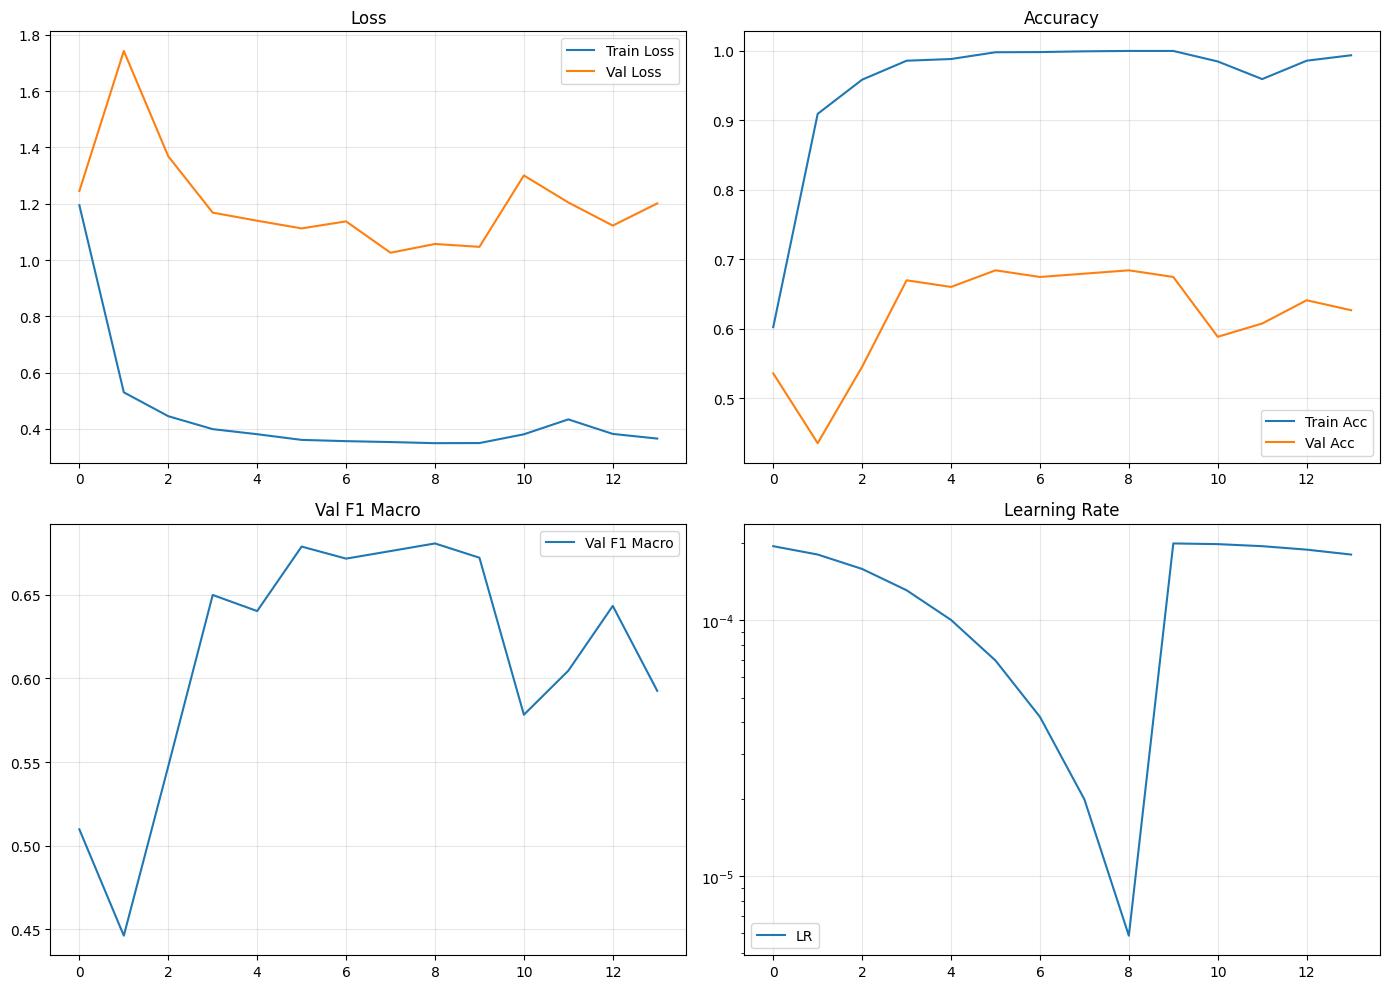

In [7]:
# Ejecutar entrenamiento

model, metrics_test, history = run_training(
    train_loader, val_loader, test_loader, class_names=train_ds.class_names,
    variant=VARIANT, backbone=BACKBONE, optimizer_name=OPTIMIZER,
    lr=INIT_LR, weight_decay=WEIGHT_DECAY, loss_name=LOSS_NAME, gamma=FOCAL_GAMMA,
    label_smoothing=LABEL_SMOOTH, epochs=EPOCHS, patience=PATIENCE, dropout=DROPOUT,
    outdir=OUTDIR, device=DEVICE, use_cbam=True
)


In [8]:
# =========================
# FINETUNING CONTROLADO DESDE MEJOR MODELO
# =========================
import torch, os, time
from tqdm.auto import tqdm

# Configuración
FINETUNE_LR = 1e-4
FINETUNE_WD = 1e-3
FINETUNE_EPOCHS = 15
FINETUNE_PATIENCE = 5
FINETUNE_DROPOUT = 0.6

ckpt_path = os.path.join(OUTDIR, f"best_{VARIANT}_{BACKBONE}.pth")
assert os.path.exists(ckpt_path), f"No se encontró el checkpoint: {ckpt_path}"
print(f"Cargando pesos desde: {ckpt_path}")

# Cargar modelo base
model = build_model(
    num_classes=len(train_ds.class_names),
    variant=VARIANT,
    backbone=BACKBONE,
    dropout=FINETUNE_DROPOUT,
    use_cbam=True
).to(DEVICE)

checkpoint = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'], strict=False)

# 🔒 Congelar capas iniciales del backbone (solo entrenar capas superiores)
for name, param in model.features.named_parameters():
    if "layer4" not in name and "layer5" not in name:
        param.requires_grad = False

trainable_params = [p for p in model.parameters() if p.requires_grad]
print(f"Parámetros entrenables: {sum(p.numel() for p in trainable_params):,}")

# Optimizador y scheduler más estables
optimizer = torch.optim.AdamW(trainable_params, lr=FINETUNE_LR, weight_decay=FINETUNE_WD)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

# Entrenamiento corto de ajuste fino
best_val_f1 = 0
patience_counter = 0
history_ft = {"train_loss": [], "val_loss": [], "val_f1": [], "lr": []}

print("\n==============================")
print("INICIO DE FINETUNING CONTROLADO")
print("==============================\n")

for epoch in range(FINETUNE_EPOCHS):
    t0 = time.time()
    model.train()
    train_loss, train_correct, total = 0, 0, 0

    for x, y in tqdm(train_loader, desc=f"[Finetune Train] Época {epoch+1}/{FINETUNE_EPOCHS}"):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type='cuda', enabled=True):
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * x.size(0)
        train_correct += (out.argmax(1) == y).sum().item()
        total += x.size(0)

    train_loss /= total
    train_acc = train_correct / total

    # Validación
    val_loss, val_acc, val_pred, val_true, val_prob = eval_one_epoch(model, val_loader, DEVICE, criterion)
    metrics_val = compute_metrics(val_true, val_pred, y_prob=val_prob, num_classes=len(train_ds.class_names))

    scheduler.step(val_loss)

    history_ft["train_loss"].append(train_loss)
    history_ft["val_loss"].append(val_loss)
    history_ft["val_f1"].append(metrics_val["f1_macro"])
    history_ft["lr"].append(optimizer.param_groups[0]['lr'])

    print(f"\nÉpoca {epoch+1:02d}/{FINETUNE_EPOCHS} - {time.time()-t0:.1f}s")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {metrics_val['f1_macro']:.4f}\n")

    # Guardar mejor modelo
    if metrics_val['f1_macro'] > best_val_f1:
        best_val_f1 = metrics_val['f1_macro']
        save_path = os.path.join(OUTDIR, f"best_finetune_{VARIANT}_{BACKBONE}.pth")
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "val_f1_macro": best_val_f1,
            "optimizer_state_dict": optimizer.state_dict(),
            "class_to_idx": train_ds.class_to_idx
        }, save_path)
        print(f"✓ Nuevo mejor modelo guardado: {save_path}")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= FINETUNE_PATIENCE:
            print("⏹️ Early stopping: sin mejora en F1.")
            break

# Evaluar en test al final
best_ckpt = os.path.join(OUTDIR, f"best_finetune_{VARIANT}_{BACKBONE}.pth")
if os.path.exists(best_ckpt):
    checkpoint = torch.load(best_ckpt, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"\nCargado mejor modelo finetune (época {checkpoint['epoch']+1})")

te_loss, te_acc, te_pred, te_true, te_prob = eval_one_epoch(model, test_loader, DEVICE, criterion)
metrics_test_ft = compute_metrics(te_true, te_pred, y_prob=te_prob, num_classes=len(train_ds.class_names))

print("\n========== RESULTADOS TEST (FINETUNING) ==========")
print(f"Accuracy:  {metrics_test_ft['acc']:.4f}")
print(f"F1_macro:  {metrics_test_ft['f1_macro']:.4f}")
print(f"mAP_macro: {metrics_test_ft.get('mAP_macro', float('nan')):.4f}")


Cargando pesos desde: .\best_pretrained_r2plus1d_18.pth


C:\Users\Cesar\AppData\Local\Temp\ipykernel_29116\2430173747.py:43: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))


Parámetros entrenables: 1,183,502

INICIO DE FINETUNING CONTROLADO



[Finetune Train] Época 1/15: 100%|██████████| 116/116 [04:44<00:00,  2.45s/it]



Época 01/15 - 348.5s
Train Loss: 0.6141 | Train Acc: 0.9997
Val Loss:   1.5472 | Val Acc: 0.6651 | Val F1: 0.6613

✓ Nuevo mejor modelo guardado: .\best_finetune_pretrained_r2plus1d_18.pth


...


Época 05/15 - 396.7s
Train Loss: 0.5970 | Train Acc: 0.9997
Val Loss:   1.5254 | Val Acc: 0.6746 | Val F1: 0.6708



[Finetune Train] Época 6/15: 100%|██████████| 116/116 [05:31<00:00,  2.85s/it]



Época 06/15 - 395.9s
Train Loss: 0.5958 | Train Acc: 1.0000
Val Loss:   1.5684 | Val Acc: 0.6699 | Val F1: 0.6651



[Finetune Train] Época 7/15:   1%|          | 1/116 [00:04<08:06,  4.23s/it]


KeyboardInterrupt: 

Evaluando en dispositivo: cuda

Cargando modelo desde: C:\Users\Cesar\Desktop\Sign_Recognition\ModelV10\best_pretrained_r2plus1d_18.pth
✓ Modelo cargado correctamente



========== RESULTADOS EN TEST ==========
Accuracy:   0.5810
F1_macro:   0.5917
F1_micro:   0.5810
mAP_macro:  0.6222

Reporte de clasificación (por clase):
              precision    recall  f1-score   support

       A ver     0.4000    0.4000    0.4000        15
    Aburrido     0.3333    0.1250    0.1818        16
     Cansado     0.6364    0.8750    0.7368        16
    Disgusto     0.1071    0.2143    0.1429        14
       Feliz     0.8667    0.8667    0.8667        15
   Huele mal     0.2941    0.3333    0.3125        15
      Ladron     0.8571    0.4000    0.5455        15
      Llorar     0.8750    0.4667    0.6087        15
     Molesto     0.9286    0.9286    0.9286        14
          No     0.6000    0.4000    0.4800        15
       No sé     0.3448    0.6667    0.4545        15
          Si     1.0000    0.6667    0.8000        15
    Sorpresa     1.0000    0.8000    0.8889        15
      Triste     0.8824    1.0000    0.9375        15

    accuracy                   

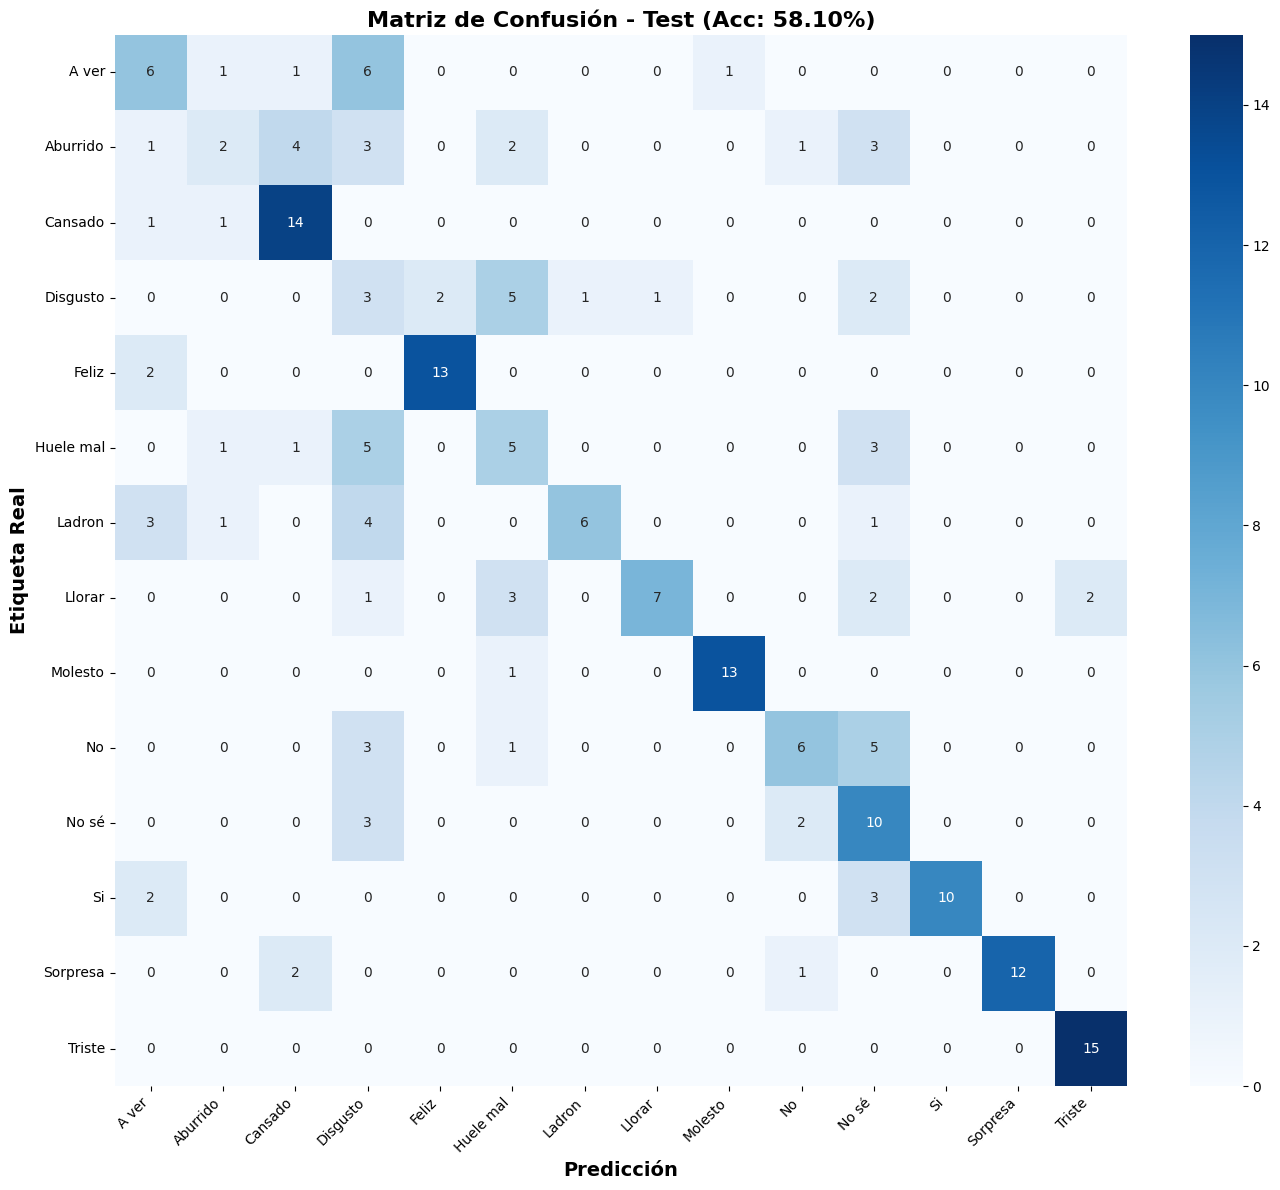

✓ Matriz de confusión guardada en: C:\Users\Cesar\Desktop\Sign_Recognition\ModelV10\confusion_matrix_best_pretrained_r2plus1d_18.png


In [9]:
# Evaluación de modelo .pth ya entrenado

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# ==================================================
# CONFIGURACIÓN
# ==================================================
OUTDIR = r"C:\Users\Cesar\Desktop\Sign_Recognition\ModelV10"
MODEL_NAME = "best_pretrained_r2plus1d_18.pth"  # <-- cambia aquí tu modelo .pth
MODEL_PATH = os.path.join(OUTDIR, MODEL_NAME)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Evaluando en dispositivo: {DEVICE}")
assert os.path.exists(MODEL_PATH), f"No se encontró el modelo: {MODEL_PATH}"

# ==================================================
# CARGA DEL MODELO
# ==================================================
print(f"\nCargando modelo desde: {MODEL_PATH}")
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

# 🔹 Recuperar información del checkpoint si existe
num_classes = len(train_ds.class_names) if 'class_to_idx' not in checkpoint else len(checkpoint['class_to_idx'])
class_names = sorted(train_ds.class_names) if 'class_to_idx' not in checkpoint else sorted(checkpoint['class_to_idx'].keys())

# 🔹 Construir modelo con misma configuración que en entrenamiento
model = build_model(
    num_classes=num_classes,
    variant="pretrained",
    backbone="r2plus1d_18",
    dropout=0.5,
    use_cbam=True
).to(DEVICE)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("✓ Modelo cargado correctamente")

# ==================================================
# EVALUACIÓN
# ==================================================
# Usa la misma función de pérdida que en entrenamiento
criterion = FocalLoss(gamma=2.0, label_smoothing=0.05)

# Ejecutar evaluación en test_loader
with torch.no_grad():
    te_loss, te_acc, te_pred, te_true, te_prob = eval_one_epoch(model, test_loader, DEVICE, criterion)

metrics_test = compute_metrics(te_true, te_pred, y_prob=te_prob, num_classes=num_classes)

print("\n========== RESULTADOS EN TEST ==========")
print(f"Accuracy:   {metrics_test['acc']:.4f}")
print(f"F1_macro:   {metrics_test['f1_macro']:.4f}")
print(f"F1_micro:   {metrics_test['f1_micro']:.4f}")
print(f"mAP_macro:  {metrics_test.get('mAP_macro', float('nan')):.4f}")

# ==================================================
# REPORTE DETALLADO
# ==================================================
print("\nReporte de clasificación (por clase):")
report = classification_report(te_true, te_pred, target_names=class_names, digits=4)
print(report)

# Guardar el reporte
report_path = os.path.join(OUTDIR, f"report_{os.path.splitext(MODEL_NAME)[0]}.txt")
with open(report_path, "w", encoding="utf-8") as f:
    f.write("REPORTE DE CLASIFICACIÓN - TEST\n" + "="*60 + "\n\n")
    f.write(f"Modelo: {MODEL_NAME}\n\n")
    f.write(f"Accuracy: {metrics_test['acc']:.4f}\n")
    f.write(f"F1_macro: {metrics_test['f1_macro']:.4f}\n")
    f.write(f"mAP_macro: {metrics_test.get('mAP_macro', float('nan')):.4f}\n\n")
    f.write(report)
print(f"✓ Reporte guardado en: {report_path}")

# ==================================================
# MATRIZ DE CONFUSIÓN
# ==================================================
cm = confusion_matrix(te_true, te_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicción", fontsize=14, fontweight="bold")
plt.ylabel("Etiqueta Real", fontsize=14, fontweight="bold")
plt.title(f"Matriz de Confusión - Test (Acc: {metrics_test['acc']:.2%})",
          fontsize=16, fontweight="bold")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

cm_path = os.path.join(OUTDIR, f"confusion_matrix_{os.path.splitext(MODEL_NAME)[0]}.png")
plt.savefig(cm_path, dpi=300)
plt.show()
print(f"✓ Matriz de confusión guardada en: {cm_path}")
